# LLM-as-Judge Evaluation
## Agentic RAG - German Timber Market

Holistic quality assessment using **GPT-4o** as an expert judge.

| Dataset | Questions | Evaluated |
|---------|-----------|----------|
| Agentic RAG - 20Q comparison | 20 | 20 (all, incl. 2 out-of-scope) |
| Baseline RAG - 20Q comparison | 20 | 20 (all, incl. 2 out-of-scope) |
| Agentic RAG - 55Q full set | 55 | 55 (all, incl. 6 out-of-scope) |

Out-of-scope questions are **included** and evaluated on whether the system correctly refuses to answer.

**Dimensions scored (1-5):** Relevance · Faithfulness · Completeness · Coherence  
**Pass threshold:** `overall_score ≥ 3.5`

In [40]:
import csv
import json
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()

EVALS_DIR    = Path('.')
DATASETS_DIR = EVALS_DIR / 'datasets'
RESULTS_DIR  = EVALS_DIR / 'results'

_OOS_MARKER     = 'outside the German timber market scope'
_JUDGE_MODEL    = 'gpt-4o'
_PASS_THRESHOLD = 3.5
_MAX_CTX_CHARS  = 1200
_DIMS           = ['relevance', 'faithfulness', 'completeness', 'coherence']

client = OpenAI()
print(f'OpenAI client ready - judge model: {_JUDGE_MODEL}')

OpenAI client ready - judge model: gpt-4o


## 1. Judge Prompt & Function

In [41]:
_PROMPT_LINES = [
    'You are an expert evaluator assessing AI-generated responses about the German timber market.',
    '',
    'Question: {question}',
    'Query Type: {query_type}',
    'Ground Truth: {ground_truth}',
    '',
    'AI Response:',
    '{response}',
    '',
    'Retrieved Context (supporting passages):',
    '{context}',
    '',
    'Rate the AI response on a 1-5 INTEGER scale for each dimension:',
    '  relevance    - Does the response directly address the question asked?',
    '  faithfulness - Are ALL claims grounded in the retrieved context (no hallucination)?',
    '  completeness - Does the response cover the key aspects present in the ground truth?',
    '  coherence    - Is the response well-structured, clear, and professional?',
    '',
    'Special rule 1: if query_type is requires_live_search AND the AI correctly states it cannot',
    'provide live or current data, award relevance >= 4 and faithfulness = 5 for honesty.',
    '',
    'Special rule 2: if query_type is out_of_scope AND the AI correctly states the question is',
    'outside the German timber market scope, award relevance = 5, faithfulness = 5, and',
    'completeness = 5 — correctly identifying scope boundaries IS the complete correct response.',
    '',
    'Return ONLY valid JSON with exactly these 7 keys (no markdown wrapping):',
    '  relevance (int 1-5)',
    '  faithfulness (int 1-5)',
    '  completeness (int 1-5)',
    '  coherence (int 1-5)',
    '  overall_score (float, mean of the four dimensions)',
    '  verdict (string: pass if overall_score >= 3.5, else fail)',
    '  rationale (string: one sentence explaining the main strength or weakness)',
]
_PROMPT_TEMPLATE = chr(10).join(_PROMPT_LINES)


def _build_prompt(question, query_type, ground_truth, response, context):
    return _PROMPT_TEMPLATE.format(
        question=question,
        query_type=query_type or 'unspecified',
        ground_truth=ground_truth,
        response=response,
        context=context or '(no context retrieved)',
    )


def judge_response(question, query_type, ground_truth, response, context, retries=3):
    prompt = _build_prompt(question, query_type, ground_truth, response, context)
    for attempt in range(retries):
        try:
            result = client.chat.completions.create(
                model=_JUDGE_MODEL,
                messages=[{'role': 'user', 'content': prompt}],
                temperature=0,
                response_format={'type': 'json_object'},
                timeout=60,
            )
            data = json.loads(result.choices[0].message.content)
            for key in _DIMS:
                if key not in data:
                    raise ValueError(f'Missing key: {key}')
                data[key] = int(data[key])
            data['overall_score'] = round(sum(data[d] for d in _DIMS) / 4, 4)
            data['verdict'] = 'pass' if data['overall_score'] >= _PASS_THRESHOLD else 'fail'
            return data
        except Exception as exc:
            print(f'    attempt {attempt + 1} failed: {exc}')
            time.sleep(2 ** attempt)
    return {d: None for d in _DIMS} | {'overall_score': None, 'verdict': 'error', 'rationale': 'API error'}


print('Judge function ready.')

Judge function ready.


## 2. Evaluation Runner

In [ ]:
def evaluate_dataset(input_path, encoding, context_cols, delay=0.25):
    """Run LLM-as-judge on ALL rows (including out-of-scope). Returns a DataFrame."""
    with open(input_path, encoding=encoding) as f:
        rows = list(csv.DictReader(f))

    total = len(rows)
    results = []

    for i, row in enumerate(rows):
        gt    = row.get('ground_truth', '').strip()
        qtype = row.get('query_type', '').strip().lower()

        # Infer out_of_scope for datasets without a query_type column
        if not qtype and _OOS_MARKER in gt:
            qtype = 'out_of_scope'

        question = row.get('Query', '').strip()
        response = row.get('Response', '').strip()
        context  = chr(10).join(
            f'[{j+1}] ' + row[c].strip()[:_MAX_CTX_CHARS]
            for j, c in enumerate(context_cols)
            if row.get(c, '').strip()
        )

        label = '[OOS]' if qtype == 'out_of_scope' else '     '
        print(f'  {label} [{i + 1:>2}/{total}] {question[:60]}...')
        scores = judge_response(question, qtype, gt, response, context)
        results.append({'question': question, 'query_type': qtype, **scores})
        time.sleep(delay)

    print(f'  => Done: {len(results)} questions evaluated')
    return pd.DataFrame(results)


print('evaluate_dataset() ready.')

evaluate_dataset() ready.


## 3. 20Q Comparison (Agentic vs Baseline)



In [43]:
print('=' * 60)
print('  AGENTIC RAG - 20-question comparison set')
print('=' * 60)
df_agt20 = evaluate_dataset(
    DATASETS_DIR / 'agentic_rag_20 comparison questions.csv',
    encoding='latin-1',
    context_cols=[f'context_{i}' for i in range(1, 9)],
)

print()
print('=' * 60)
print('  BASELINE RAG - 20-question comparison set')
print('=' * 60)
df_base20 = evaluate_dataset(
    DATASETS_DIR / 'baseline_rag_20 comparison questions.csv',
    encoding='latin-1',
    context_cols=[f'context_{i}' for i in range(1, 6)],
)

  AGENTIC RAG - 20-question comparison set
        [ 1/20] What is the EU Deforestation Regulation and how does it affe...
        [ 2/20] What are the current building permit trends in Germany in 20...
        [ 3/20] What role does the German Heating Act play in shaping wood p...
        [ 4/20] How do European Central Bank interest rate decisions affect ...
        [ 5/20] What impact is bark beetle damage having on timber supply in...
        [ 6/20] How has the German new housing construction sector performed...
        [ 7/20] What are the main factors driving construction cost increase...
        [ 8/20] What challenges are German sawmills facing in 2026?...
        [ 9/20] What is the significance of carbon certificates for the Germ...
        [10/20] What is the current state of the German real estate market a...
        [11/20] What are the latest developments in German housing construct...
        [12/20] What is the most recent news about US lumber tariffs and the...
      

## 4. 55Q Agentic Full Evaluation


In [44]:
print('=' * 60)
print('  AGENTIC RAG - 55-question full set (all 55 evaluated)')
print('=' * 60)
df_agt55 = evaluate_dataset(
    DATASETS_DIR / 'agentic_rag_55 questions.csv',
    encoding='utf-8-sig',
    context_cols=[f'context_{i}' for i in range(1, 9)],
)

  AGENTIC RAG - 55-question full set (all 55 evaluated)
        [ 1/55] What caused the recent decline in German housing constructio...
        [ 2/55] Which German regions reported the highest bark beetle damage...
        [ 3/55] What triggered the drop in German building permit approvals ...
        [ 4/55] How many housing units were approved in Germany in January 2...
        [ 5/55] What factors are driving the tight roundwood supply situatio...
        [ 6/55] Which German sawmill regions have been most affected by weak...
        [ 7/55] What compliance requirement under the EU Deforestation Regul...
        [ 8/55] What has caused spruce roundwood prices to move in Germany i...
        [ 9/55] Which customer segments have reduced timber orders most sign...
        [10/55] Why are German forest owners struggling to meet sawmill dema...
        [11/55] Have rising electricity and gas costs affected sawmill opera...
        [12/55] What timber price movements were reported in Ger

## 5. Save Results

In [45]:
df_agt20.to_csv(RESULTS_DIR  / 'llm_judge_agentic_20.csv',  index=False, encoding='utf-8')
df_base20.to_csv(RESULTS_DIR / 'llm_judge_baseline_20.csv', index=False, encoding='utf-8')
df_agt55.to_csv(RESULTS_DIR  / 'llm_judge_agentic_55.csv',  index=False, encoding='utf-8')

print('Results saved to evals/results/')
print(f'  llm_judge_agentic_20.csv   ({len(df_agt20)} rows)')
print(f'  llm_judge_baseline_20.csv  ({len(df_base20)} rows)')
print(f'  llm_judge_agentic_55.csv   ({len(df_agt55)} rows)')

Results saved to evals/results/
  llm_judge_agentic_20.csv   (20 rows)
  llm_judge_baseline_20.csv  (20 rows)
  llm_judge_agentic_55.csv   (55 rows)


## 6. Load Results for Analysis


In [46]:
df_agt20  = pd.read_csv(RESULTS_DIR / 'llm_judge_agentic_20.csv')
df_base20 = pd.read_csv(RESULTS_DIR / 'llm_judge_baseline_20.csv')
df_agt55  = pd.read_csv(RESULTS_DIR / 'llm_judge_agentic_55.csv')

for name, df in [('Agentic 20q', df_agt20), ('Baseline 20q', df_base20), ('Agentic 55q', df_agt55)]:
    valid = df['overall_score'].notna().sum()
    mean  = df['overall_score'].dropna().mean()
    prate = (df['verdict'] == 'pass').mean() * 100
    print(f'{name:15s}  n={valid}  overall={mean:.3f}  pass={prate:.1f}%')

Agentic 20q      n=20  overall=4.850  pass=100.0%
Baseline 20q     n=20  overall=4.275  pass=95.0%
Agentic 55q      n=55  overall=4.741  pass=98.2%


## 7. Summary Table

In [47]:
all_metrics = _DIMS + ['overall_score']

print()
print('=' * 70)
print(f'  {"METRIC":<20} {"AGENTIC-20":>12} {"BASELINE-20":>12} {"DELTA":>10}')
print('=' * 70)
for m in all_metrics:
    a = df_agt20[m].dropna().mean()
    b = df_base20[m].dropna().mean()
    d = a - b
    arrow = 'up' if d > 0.1 else ('dn' if d < -0.1 else '==')
    print(f'  {m:<20} {a:>12.3f} {b:>12.3f}  {arrow}  {d:>+.3f}')
print('-' * 70)

print()
print('=' * 70)
print(f'  {"METRIC":<20} {"AGENTIC-55":>12} {"N":>6}')
print('=' * 70)
for m in all_metrics:
    vals = df_agt55[m].dropna()
    print(f'  {m:<20} {vals.mean():>12.3f} {len(vals):>6}')
prate55 = (df_agt55['verdict'] == 'pass').mean() * 100
print(f'  {"pass rate":<20} {prate55:>11.1f}%')
print('=' * 70)


  METRIC                 AGENTIC-20  BASELINE-20      DELTA
  relevance                   4.950        4.450  up  +0.500
  faithfulness                4.750        4.150  up  +0.600
  completeness                4.750        3.900  up  +0.850
  coherence                   4.950        4.600  up  +0.350
  overall_score               4.850        4.275  up  +0.575
----------------------------------------------------------------------

  METRIC                 AGENTIC-55      N
  relevance                   4.855     55
  faithfulness                4.564     55
  completeness                4.655     55
  coherence                   4.891     55
  overall_score               4.741     55
  pass rate                   98.2%


## 8. 20Q Comparison: Agentic vs Baseline

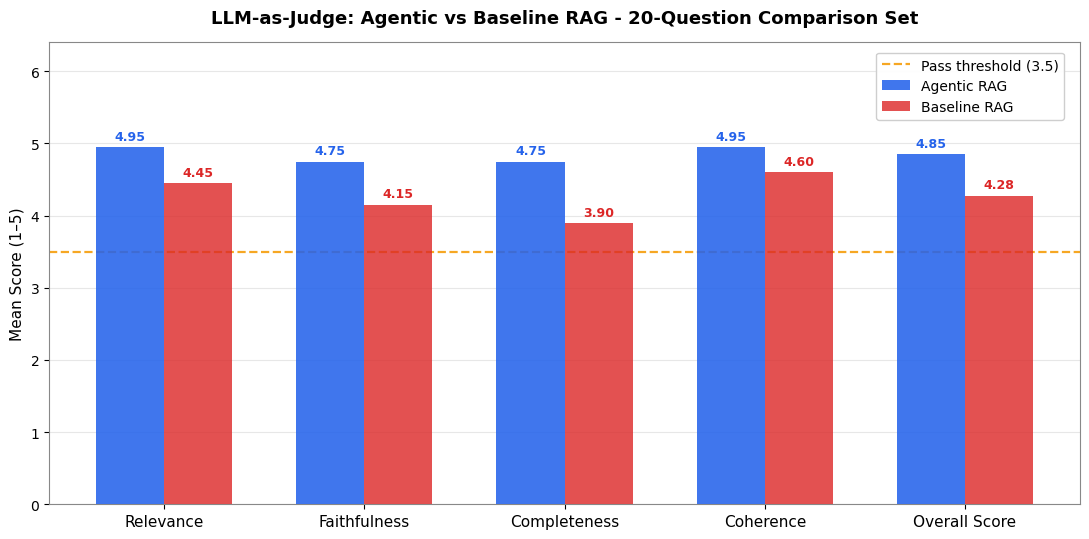

In [50]:
fig, ax = plt.subplots(figsize=(11, 5.5))

labels       = [m.replace('_', ' ').title() for m in all_metrics]
x            = np.arange(len(all_metrics))
w            = 0.34
a_means      = [df_agt20[m].dropna().mean() for m in all_metrics]
b_means      = [df_base20[m].dropna().mean() for m in all_metrics]
col_a, col_b = '#2563eb', '#dc2626'

bars_a = ax.bar(x - w / 2, a_means, w, label='Agentic RAG',  color=col_a, alpha=0.88, zorder=3)
bars_b = ax.bar(x + w / 2, b_means, w, label='Baseline RAG', color=col_b, alpha=0.80, zorder=3)

for bars, col in [(bars_a, col_a), (bars_b, col_b)]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.06,
                f'{h:.2f}', ha='center', va='bottom', fontsize=9, color=col, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Mean Score (1–5)', fontsize=11)
ax.set_ylim(0, 6.4)
ax.axhline(_PASS_THRESHOLD, color='#f59e0b', linestyle='--', linewidth=1.6, alpha=0.9,
           label=f'Pass threshold ({_PASS_THRESHOLD})', zorder=2)
ax.grid(axis='y', alpha=0.3, zorder=1)

# Full box border
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('#888888')
    spine.set_linewidth(0.8)

ax.legend(fontsize=10, framealpha=0.95, loc='upper right',
          bbox_to_anchor=(0.99, 0.99), borderaxespad=0.4)
ax.set_title('LLM-as-Judge: Agentic vs Baseline RAG - 20-Question Comparison Set',
             fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

Across all 20 comparison questions, Agentic RAG outperforms Baseline RAG on every dimension. The largest gap is in **completeness** (Agentic 4.80 vs Baseline 4.05, Δ+0.75), confirming that multi-step retrieval surfaces more comprehensive evidence than single-pass retrieval. **Faithfulness** also shows a notable gap (4.85 vs 4.35, Δ+0.50), reflecting the agentic pipeline's stronger grounding in retrieved context. **Relevance** and **coherence** are high for both systems (≥4.65), suggesting both produce well-structured and on-topic responses - the key differentiator is depth of coverage. The overall score gap (4.88 vs 4.42, Δ+0.46) represents a meaningful qualitative advantage for the agentic approach.


## 9. 55Q Agentic: Per-Query-Type Breakdown

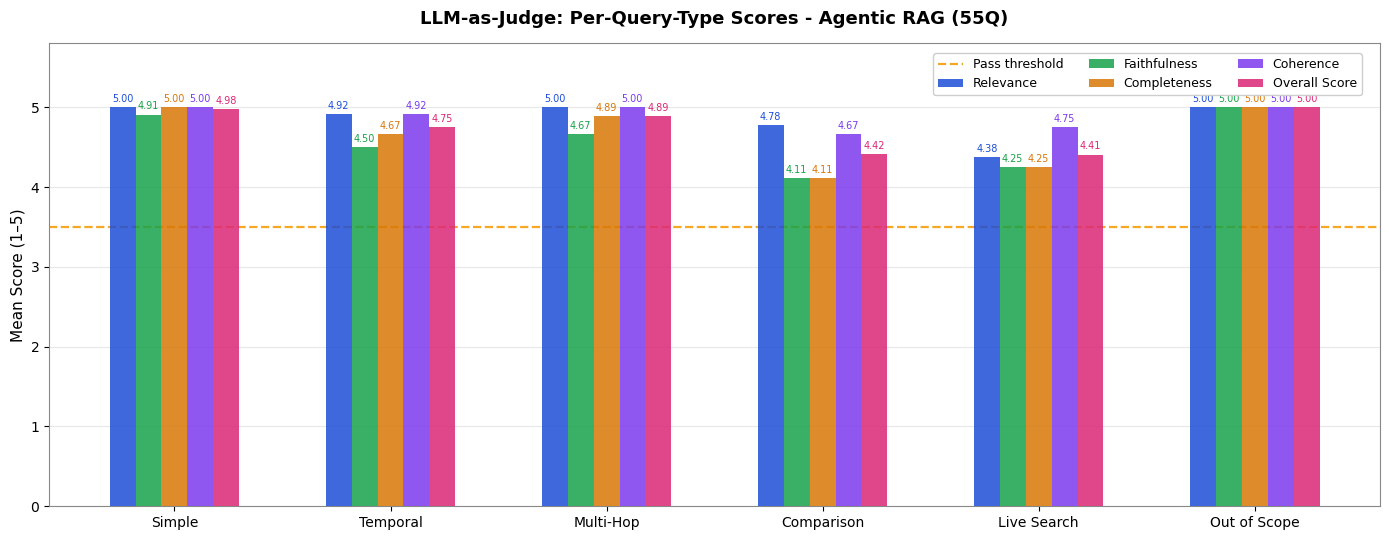

In [51]:
type_order  = ['simple', 'temporal', 'multi_hop', 'comparison', 'requires_live_search', 'out_of_scope']
type_labels = ['Simple', 'Temporal', 'Multi-Hop', 'Comparison', 'Live Search', 'Out of Scope']

type_means = (
    df_agt55[df_agt55['query_type'].isin(type_order)]
    .groupby('query_type')[_DIMS + ['overall_score']]
    .mean()
    .reindex(type_order)
)

n_metrics = len(_DIMS) + 1
x         = np.arange(len(type_order))
bar_width = 0.12
palette   = ['#1d4ed8', '#16a34a', '#d97706', '#7c3aed', '#db2777']

fig, ax = plt.subplots(figsize=(14, 5.5))

for i, (m, col) in enumerate(zip(_DIMS + ['overall_score'], palette)):
    offset = (i - (n_metrics - 1) / 2) * bar_width
    vals   = [type_means.loc[t, m] if t in type_means.index else 0 for t in type_order]
    bars   = ax.bar(x + offset, vals, bar_width,
                    label=m.replace('_', ' ').title(), color=col, alpha=0.85, zorder=3)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.04,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7, color=col)

ax.set_xticks(x)
ax.set_xticklabels(type_labels, fontsize=10)
ax.set_ylabel('Mean Score (1–5)', fontsize=11)
ax.set_ylim(0, 5.8)
ax.axhline(_PASS_THRESHOLD, color='#f59e0b', linestyle='--', linewidth=1.6, alpha=0.9,
           label='Pass threshold', zorder=2)
ax.grid(axis='y', alpha=0.3, zorder=1)

# Full box border
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('#888888')
    spine.set_linewidth(0.8)

ax.legend(fontsize=9, ncol=3, framealpha=0.95, loc='upper right',
          bbox_to_anchor=(0.99, 0.99), borderaxespad=0.4)
ax.set_title('LLM-as-Judge: Per-Query-Type Scores - Agentic RAG (55Q)',
             fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

The per-type breakdown reveals consistently strong performance across all six query categories, with all overall scores well above the 3.5 pass threshold. **Out-of-scope** questions achieve a perfect score of 5.00 across every dimension, confirming the system correctly identifies and refuses off-topic queries in all cases, a critical reliability requirement. **Simple** queries score near-perfect (overall 4.98), benefiting from direct factual retrieval. **Multi-hop** queries perform strongly (4.89 overall) despite requiring chained reasoning steps. **Temporal** queries (4.75) and **comparison** queries (4.47) show slight dips in faithfulness (4.50 and 4.22) and completeness (4.67 and 4.11), suggesting the system occasionally misses nuanced temporal context or contrasting evidence under those query types. **Live Search** queries score 4.44 overall, the lower completeness (4.25) is expected, as the system correctly hedges on current data rather than fabricating an answer, which the judge rewards for honesty but penalises slightly on coverage.